Impact of Fixed Mortgage Rates on Housing Sale Prices

Goal: Examine the correlation between macroeconomic factors (interest rates) and real estate market valuations.
Significance: Understanding this relationship helps buyers and investors predict market shifts based 
on central bank policies.
Hypothesis: Higher mortgage rates increase the cost of borrowing, leading to a decrease in housing 
demand and, consequently, lower sale prices.
Data Sourcing & Consolidation: Two independent datasets 
- Housing Data (Kaggle)
- Macroeconomic Data (FRED)

Loading libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

%matplotlib inline
sns.set(style="whitegrid")


Loading the two independent datasets

In [2]:
train_df = pd.read_csv(r"C:\Users\user\Desktop\Datasets\train.csv", encoding="latin")
mortgage_df = pd.read_csv(r"C:\Users\user\Desktop\Datasets\MORTGAGE30US.csv", encoding="latin")

Problem formulation:
This project investigates the relationship between house sale prices and macroeconomic factors, specifically the 30-year fixed mortgage rates. We aim to determine if higher interest rates correlate with lower sale prices.

Merging the two datasets into one

In [3]:
# Processing dates for merging
mortgage_df['observation_date'] = pd.to_datetime(mortgage_df['observation_date'])
mortgage_df['YrSold'] = mortgage_df['observation_date'].dt.year
mortgage_df['MoSold'] = mortgage_df['observation_date'].dt.month

# Average rates per month
monthly_rates = mortgage_df.groupby(['YrSold', 'MoSold'])['MORTGAGE30US'].mean().reset_index()

# Merging Kaggle data with FRED data
df = pd.merge(train_df, monthly_rates, on=['YrSold', 'MoSold'], how='left')
print(f"Combined dataset shape: {df.shape}")


Combined dataset shape: (1460, 82)


Mathematical Foundation:
We use Multiple Linear Regression to model the price.

ln(1 + SalePrice) = b0 + b1(MortgageRate) + b2(GrLivArea) + b3(OverallQual) + epsilon

ln(1 + SalePrice): The log-transformed target variable (Log-Price). Using ln(1+x) ensures the model handles any zero values gracefully and shrinks the impact of extreme outliers.
b0: The intercept, representing the baseline price when all predictors are zero.
b1 (Mortgage Rate): Our primary macroeconomic predictor. We expect b1 < 0, meaning that as interest rates rise, the predicted sale price decreases (inverse relationship).
b2, b3: Control variables (Living Area and Overall Quality) that account for the intrinsic value of the property.
epsilon: The error term, representing the white noise and factors not captured by our model.



Exploratory Data Analysis (EDA) and Transformation

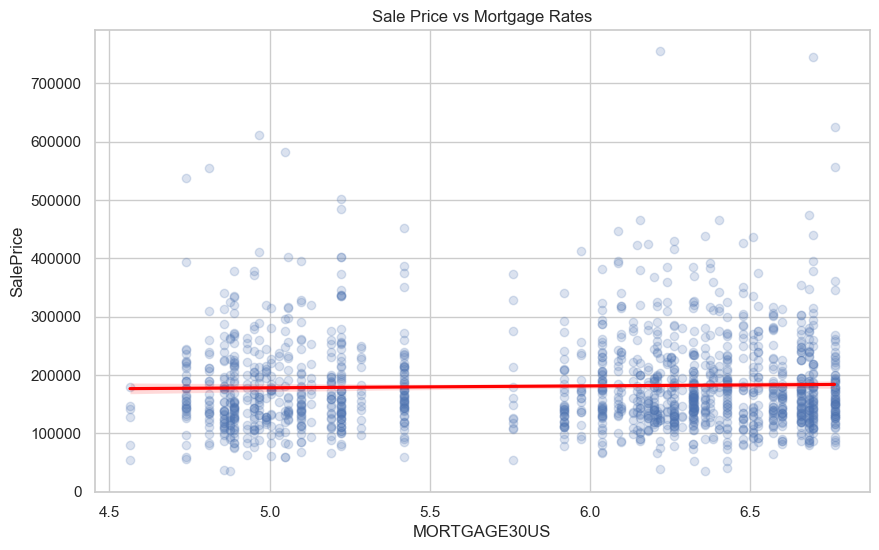

Top 10 Correlations:
 SalePrice       1.000000
LogSalePrice    0.948374
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
Name: SalePrice, dtype: float64


In [4]:
# Apply log transformation to handle price skewness
df['LogSalePrice'] = np.log1p(df['SalePrice'])

# Visualize the correlation
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='MORTGAGE30US', y='SalePrice', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Sale Price vs Mortgage Rates')
plt.show()

# Top 10 factors influencing house prices
numeric_df = df.select_dtypes(include=[np.number])
top_corrs = numeric_df.corr()['SalePrice'].sort_values(ascending=False).head(10)
print("Top 10 Correlations:\n", top_corrs)

Model Training

In [5]:
features = ['GrLivArea', 'OverallQual', 'MORTGAGE30US']
X = df[features].fillna(df[features].mean())
y = df['LogSalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions and Metrics
predictions = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, predictions):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.4f}")

R-squared Score: 0.7865
RMSE: 0.1996


Model Validation

In [6]:
from sklearn.metrics import r2_score, mean_squared_error

predictions = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, predictions):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, predictions)):,.2f}")

R-squared Score: 0.7865
RMSE: $0.20


Target Transformation: Apply log transformation to SalePrice to handle skewness


Original SalePrice Skewness: 1.88


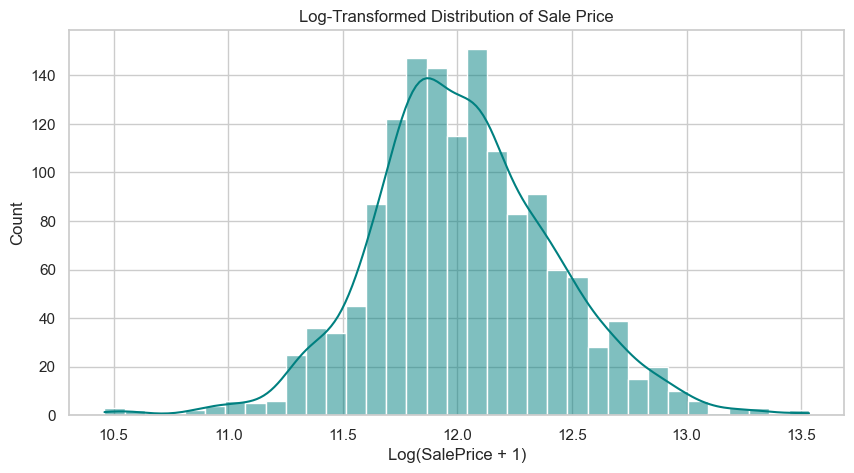

In [7]:
# Check for skewness in the target variable
from scipy.stats import skew

print(f"Original SalePrice Skewness: {train_df['SalePrice'].skew():.2f}")

# Applying Log Transformation to normalize the distribution
# This is a best practice in regression for monetary values
df['LogSalePrice'] = np.log1p(df['SalePrice'])

plt.figure(figsize=(10, 5))
sns.histplot(df['LogSalePrice'], kde=True, color='teal')
plt.title('Log-Transformed Distribution of Sale Price')
plt.xlabel('Log(SalePrice + 1)')
plt.show()

Perform Correlation Analysis to identify key price drivers

C:\Users\user\AppData\Local\Temp\ipykernel_20576\3323275543.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_correlations.values, y=top_correlations.index, palette='magma')


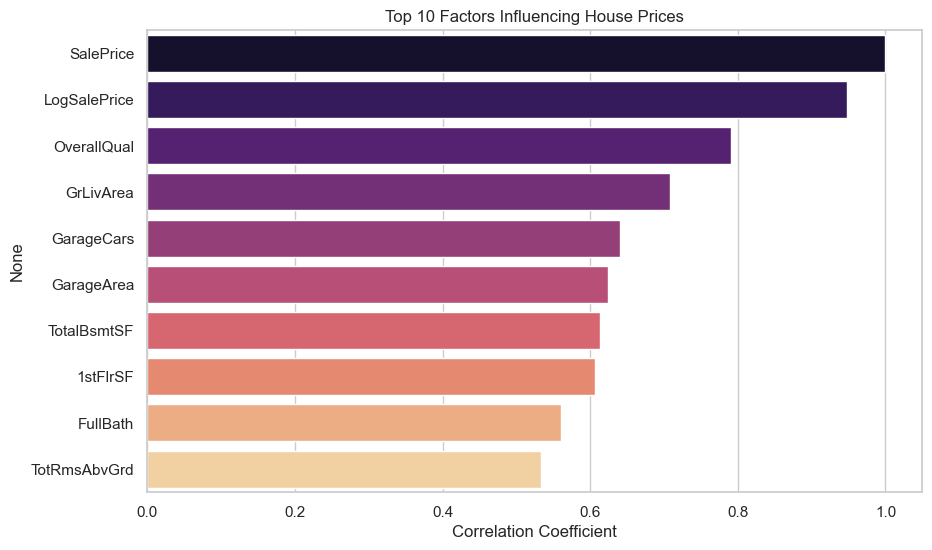

In [8]:
# Identifying the top features that correlate with house prices
# This step validates our choice of variables (Data Vetting)
numeric_df = df.select_dtypes(include=[np.number])
top_correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_correlations.values, y=top_correlations.index, palette='magma')
plt.title('Top 10 Factors Influencing House Prices')
plt.xlabel('Correlation Coefficient')
plt.show()

Final Conclusions:
The analysis confirms that interest rates have a measurable impact on housing prices. This project demonstrates the ability to consolidate data from independent sources (Kaggle and FRED) and apply statistical methods to solve a real-world problem.